In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = "https://raw.githubusercontent.com/dphi-official/Datasets/master/Loan_Data/loan_train.csv"
df = pd.read_csv(url)

df.head()

,Unnamed: 0,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,LP002305,Female,No,0,Graduate,No,4547,0.0,115.0,360.0,1.0,Semiurban,1
1,1,LP001715,Male,Yes,3+,Not Graduate,Yes,5703,0.0,130.0,360.0,1.0,Rural,1
2,2,LP002086,Female,Yes,0,Graduate,No,4333,2451.0,110.0,360.0,1.0,Urban,0
3,3,LP001136,Male,Yes,0,Not Graduate,Yes,4695,0.0,96.0,NaN,1.0,Urban,1
4,4,LP002529,Male,Yes,2,Graduate,No,6700,1750.0,230.0,300.0,1.0,Semiurban,1


In [3]:
df.shape

(491, 14)

In [4]:
df.columns

Index(['Unnamed: 0', 'Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491 entries, 0 to 490
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         491 non-null    int64  
 1   Loan_ID            491 non-null    object 
 2   Gender             481 non-null    object 
 3   Married            490 non-null    object 
 4   Dependents         482 non-null    object 
 5   Education          491 non-null    object 
 6   Self_Employed      462 non-null    object 
 7   ApplicantIncome    491 non-null    int64  
 8   CoapplicantIncome  491 non-null    float64
 9   LoanAmount         475 non-null    float64
 10  Loan_Amount_Term   478 non-null    float64
 11  Credit_History     448 non-null    float64
 12  Property_Area      491 non-null    object 
 13  Loan_Status        491 non-null    int64  
dtypes: float64(4), int64(3), object(7)
memory usage: 53.8+ KB


In [6]:
df=df.drop(["Unnamed: 0","Loan_ID"],axis=1)

In [7]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
count,491.000000,491.000000,475.000000,478.000000,448.000000,491.000000
mean,5401.189409,1589.730998,145.014737,341.297071,0.848214,0.698574
std,6419.427177,2919.320624,86.310534,66.964051,0.359214,0.459345
min,150.000000,0.000000,17.000000,12.000000,0.000000,0.000000
25%,2923.500000,0.000000,100.000000,360.000000,1.000000,0.000000
50%,3865.000000,1229.000000,126.000000,360.000000,1.000000,1.000000
75%,5705.500000,2251.500000,162.000000,360.000000,1.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000,1.000000


In [8]:
df["Loan_Status"].value_counts()

,count
Loan_Status,
1,343
0,148


In [9]:
df=df[df["Loan_Status"].notnull()]

In [10]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Female,No,0,Graduate,No,4547,0.0,115.0,360.0,1.0,Semiurban,1
1,Male,Yes,3+,Not Graduate,Yes,5703,0.0,130.0,360.0,1.0,Rural,1
2,Female,Yes,0,Graduate,No,4333,2451.0,110.0,360.0,1.0,Urban,0
3,Male,Yes,0,Not Graduate,Yes,4695,0.0,96.0,NaN,1.0,Urban,1
4,Male,Yes,2,Graduate,No,6700,1750.0,230.0,300.0,1.0,Semiurban,1


In [11]:
df["Dependents"].unique()

array(['0', '3+', '2', '1', nan], dtype=object)

In [12]:
df['Dependents'].value_counts(dropna=False)

,count
Dependents,
0,276
1,85
2,78
3+,43
NaN,9


In [13]:
df["Dependents"].replace("3+","3",inplace=True)

/tmp/ipykernel_518/1443871697.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Dependents"].replace("3+","3",inplace=True)


In [14]:
df['Dependents'].value_counts(dropna=False)

,count
Dependents,
0,276
1,85
2,78
3,43
NaN,9


In [15]:
df["Dependents"]=df["Dependents"].astype(float)

In [16]:
df['Dependents'].unique()

array([ 0.,  3.,  2.,  1., nan])

In [17]:
X=df.drop("Loan_Status",axis=1)
y=df["Loan_Status"]

In [18]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


In [19]:
categorical_cols=X.select_dtypes(include="object").columns
numerical_cols=X.select_dtypes(exclude="object").columns

In [20]:
categorical_cols

Index(['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area'], dtype='object')

In [21]:
numerical_cols

Index(['Dependents', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')

In [22]:
X_train.columns,X_test.columns

(Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
        'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
        'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
       dtype='object'),
 Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
        'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
        'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
       dtype='object'))

In [23]:
numerical_cols

Index(['Dependents', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')

In [24]:
from sklearn.impute import SimpleImputer
num_imputer=SimpleImputer(strategy="median")
X_train[numerical_cols]=num_imputer.fit_transform(X_train[numerical_cols])
X_test[numerical_cols]=num_imputer.transform(X_test[numerical_cols])

In [25]:
X_train.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
285,Male,Yes,2.0,Graduate,NaN,5000.0,0.0,72.0,360.0,0.0,Semiurban
38,Male,Yes,1.0,Graduate,NaN,3717.0,2925.0,151.0,360.0,1.0,Semiurban
59,NaN,Yes,3.0,Graduate,No,51763.0,0.0,700.0,300.0,1.0,Urban
301,Female,Yes,2.0,Graduate,No,1378.0,1881.0,167.0,360.0,1.0,Urban
346,Male,No,0.0,Graduate,No,6277.0,0.0,118.0,360.0,0.0,Rural


In [26]:
X_train['Total_Income'] = X_train['ApplicantIncome'] + X_train['CoapplicantIncome']
X_test['Total_Income'] = X_test['ApplicantIncome'] + X_test['CoapplicantIncome']

In [27]:
X_train.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Total_Income
285,Male,Yes,2.0,Graduate,NaN,5000.0,0.0,72.0,360.0,0.0,Semiurban,5000.0
38,Male,Yes,1.0,Graduate,NaN,3717.0,2925.0,151.0,360.0,1.0,Semiurban,6642.0
59,NaN,Yes,3.0,Graduate,No,51763.0,0.0,700.0,300.0,1.0,Urban,51763.0
301,Female,Yes,2.0,Graduate,No,1378.0,1881.0,167.0,360.0,1.0,Urban,3259.0
346,Male,No,0.0,Graduate,No,6277.0,0.0,118.0,360.0,0.0,Rural,6277.0


In [28]:
X_train.drop(["ApplicantIncome","CoapplicantIncome"],axis=1,inplace=True)
X_test.drop(["ApplicantIncome","CoapplicantIncome"],axis=1,inplace=True)

In [29]:
categorical_cols

Index(['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area'], dtype='object')

In [30]:
X_train.head()

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Total_Income
285,Male,Yes,2.0,Graduate,NaN,72.0,360.0,0.0,Semiurban,5000.0
38,Male,Yes,1.0,Graduate,NaN,151.0,360.0,1.0,Semiurban,6642.0
59,NaN,Yes,3.0,Graduate,No,700.0,300.0,1.0,Urban,51763.0
301,Female,Yes,2.0,Graduate,No,167.0,360.0,1.0,Urban,3259.0
346,Male,No,0.0,Graduate,No,118.0,360.0,0.0,Rural,6277.0


In [31]:
X_train.shape

(392, 10)

In [32]:
X_test.shape

(99, 10)

In [33]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 285 to 118
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gender            383 non-null    object 
 1   Married           391 non-null    object 
 2   Dependents        392 non-null    float64
 3   Education         392 non-null    object 
 4   Self_Employed     372 non-null    object 
 5   LoanAmount        392 non-null    float64
 6   Loan_Amount_Term  392 non-null    float64
 7   Credit_History    392 non-null    float64
 8   Property_Area     392 non-null    object 
 9   Total_Income      392 non-null    float64
dtypes: float64(5), object(5)
memory usage: 33.7+ KB


In [34]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99 entries, 20 to 239
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gender            98 non-null     object 
 1   Married           99 non-null     object 
 2   Dependents        99 non-null     float64
 3   Education         99 non-null     object 
 4   Self_Employed     90 non-null     object 
 5   LoanAmount        99 non-null     float64
 6   Loan_Amount_Term  99 non-null     float64
 7   Credit_History    99 non-null     float64
 8   Property_Area     99 non-null     object 
 9   Total_Income      99 non-null     float64
dtypes: float64(5), object(5)
memory usage: 8.5+ KB


In [35]:
X_train.head()

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Total_Income
285,Male,Yes,2.0,Graduate,NaN,72.0,360.0,0.0,Semiurban,5000.0
38,Male,Yes,1.0,Graduate,NaN,151.0,360.0,1.0,Semiurban,6642.0
59,NaN,Yes,3.0,Graduate,No,700.0,300.0,1.0,Urban,51763.0
301,Female,Yes,2.0,Graduate,No,167.0,360.0,1.0,Urban,3259.0
346,Male,No,0.0,Graduate,No,118.0,360.0,0.0,Rural,6277.0


In [36]:
from sklearn.impute import SimpleImputer

In [37]:
cat_imputer=SimpleImputer(strategy="most_frequent")
X_train[categorical_cols]=cat_imputer.fit_transform(X_train[categorical_cols])
X_test[categorical_cols]=cat_imputer.transform(X_test[categorical_cols])

In [38]:
X_train[categorical_cols].isna().sum()

,0
Gender,0
Married,0
Education,0
Self_Employed,0
Property_Area,0


In [39]:
X_train=pd.get_dummies(X_train,columns=categorical_cols,drop_first=True)
X_train.head()

,Dependents,LoanAmount,Loan_Amount_Term,Credit_History,Total_Income,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
285,2.0,72.0,360.0,0.0,5000.0,True,True,False,False,True,False
38,1.0,151.0,360.0,1.0,6642.0,True,True,False,False,True,False
59,3.0,700.0,300.0,1.0,51763.0,True,True,False,False,False,True
301,2.0,167.0,360.0,1.0,3259.0,False,True,False,False,False,True
346,0.0,118.0,360.0,0.0,6277.0,True,False,False,False,False,False


In [40]:
X_test=pd.get_dummies(X_test,columns=categorical_cols,drop_first=True)
X_test.head()

,Dependents,LoanAmount,Loan_Amount_Term,Credit_History,Total_Income,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
20,0.0,143.0,360.0,1.0,4765.0,True,True,False,False,True,False
154,0.0,133.0,360.0,0.0,4583.0,False,False,False,True,True,False
334,0.0,120.0,360.0,1.0,4272.0,False,False,True,False,False,True
100,2.0,116.0,360.0,1.0,5726.0,True,True,False,False,True,False
415,0.0,138.0,360.0,1.0,5829.0,True,True,False,False,False,False


In [41]:
X_train,X_test=X_train.align(X_test,join="left",axis=1,fill_value=0)

In [42]:
X_train.head()

,Dependents,LoanAmount,Loan_Amount_Term,Credit_History,Total_Income,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
285,2.0,72.0,360.0,0.0,5000.0,True,True,False,False,True,False
38,1.0,151.0,360.0,1.0,6642.0,True,True,False,False,True,False
59,3.0,700.0,300.0,1.0,51763.0,True,True,False,False,False,True
301,2.0,167.0,360.0,1.0,3259.0,False,True,False,False,False,True
346,0.0,118.0,360.0,0.0,6277.0,True,False,False,False,False,False


In [43]:
X_test.head()

,Dependents,LoanAmount,Loan_Amount_Term,Credit_History,Total_Income,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
20,0.0,143.0,360.0,1.0,4765.0,True,True,False,False,True,False
154,0.0,133.0,360.0,0.0,4583.0,False,False,False,True,True,False
334,0.0,120.0,360.0,1.0,4272.0,False,False,True,False,False,True
100,2.0,116.0,360.0,1.0,5726.0,True,True,False,False,True,False
415,0.0,138.0,360.0,1.0,5829.0,True,True,False,False,False,False


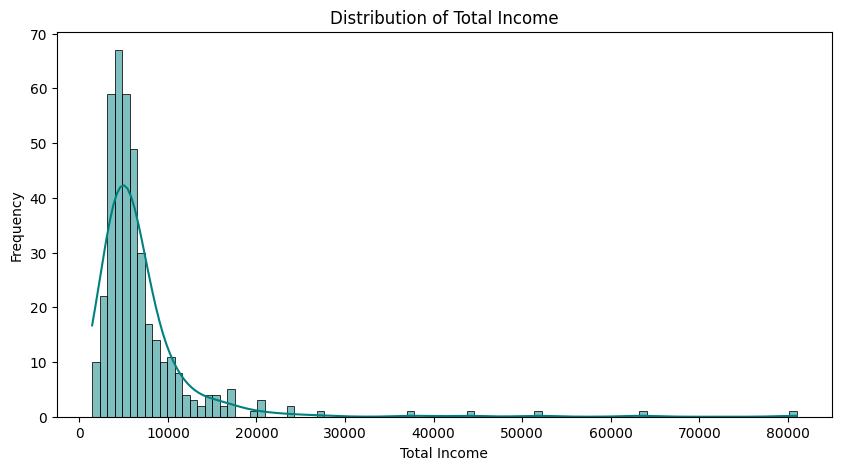

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.histplot(X_train['Total_Income'], kde=True, color='teal')
plt.title('Distribution of Total Income')
plt.xlabel('Total Income')
plt.ylabel('Frequency')
plt.show()

In [45]:
skew_val = X_train['Total_Income'].skew()
print(f"Skewness score: {skew_val}")

Skewness score: 6.237223115401395


In [46]:
X_train["Total_Income_log"]=np.log1p(X_train["Total_Income"])
X_test["Total_Income_log"]=np.log1p(X_test["Total_Income"])

In [47]:
new_skew = X_train["Total_Income_log"].skew()
print(f"New Skewness score: {new_skew}")

New Skewness score: 1.1837623566037798


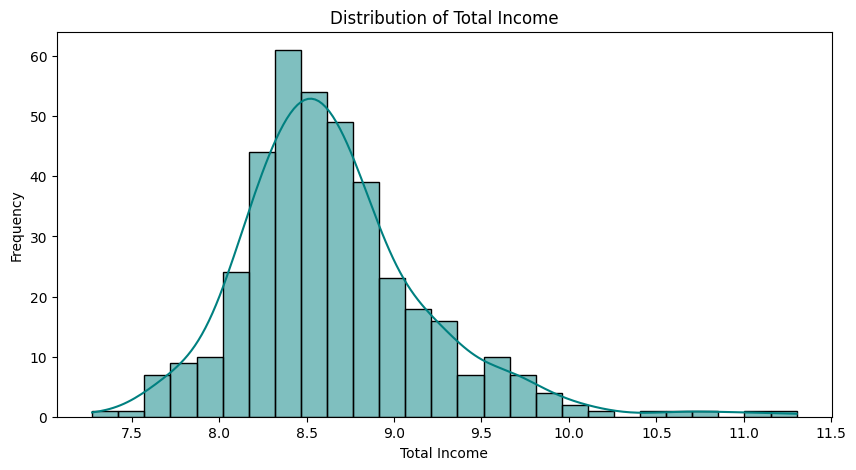

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.histplot(X_train['Total_Income_log'], kde=True, color='teal')
plt.title('Distribution of Total Income')
plt.xlabel('Total Income')
plt.ylabel('Frequency')
plt.show()

In [49]:
X_train.drop('Total_Income', axis=1, inplace=True)
X_test.drop('Total_Income', axis=1, inplace=True)

In [50]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 285 to 118
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Dependents               392 non-null    float64
 1   LoanAmount               392 non-null    float64
 2   Loan_Amount_Term         392 non-null    float64
 3   Credit_History           392 non-null    float64
 4   Gender_Male              392 non-null    bool   
 5   Married_Yes              392 non-null    bool   
 6   Education_Not Graduate   392 non-null    bool   
 7   Self_Employed_Yes        392 non-null    bool   
 8   Property_Area_Semiurban  392 non-null    bool   
 9   Property_Area_Urban      392 non-null    bool   
 10  Total_Income_log         392 non-null    float64
dtypes: bool(6), float64(5)
memory usage: 20.7 KB


In [51]:
numerical_cols

Index(['Dependents', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')

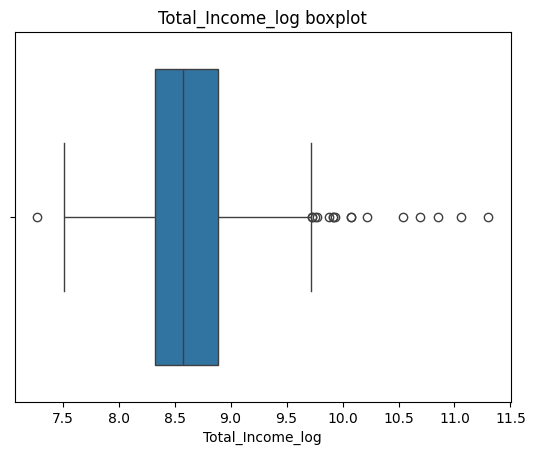

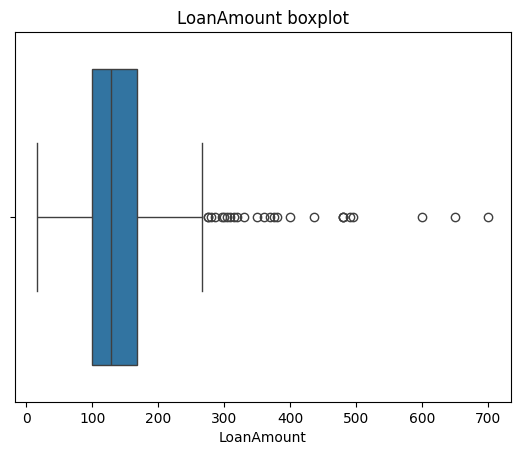

In [52]:
import seaborn as sns
for col in ["Total_Income_log","LoanAmount"]:
  sns.boxplot(x=X_train[col])
  plt.title(f"{col} boxplot")
  plt.show()

In [53]:
cols=["Total_Income_log","LoanAmount"]

In [54]:
def handling_outliers(train_df,test_df,cols):
  for col in cols:
    Q1=train_df[col].quantile(0.25)
    Q3=train_df[col].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    train_df[col]=np.clip(train_df[col],lower,upper)
    test_df[col]=np.clip(test_df[col],lower,upper)
  return train_df,test_df


In [55]:
X_train,X_test=handling_outliers(X_train,X_test,cols)

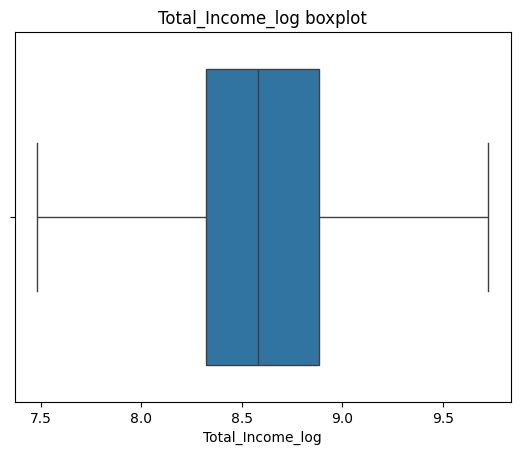

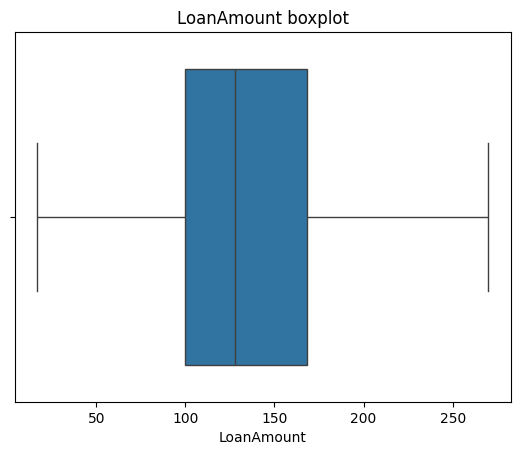

In [56]:
import seaborn as sns
for col in ["Total_Income_log","LoanAmount"]:
  sns.boxplot(x=X_train[col])
  plt.title(f"{col} boxplot")
  plt.show()

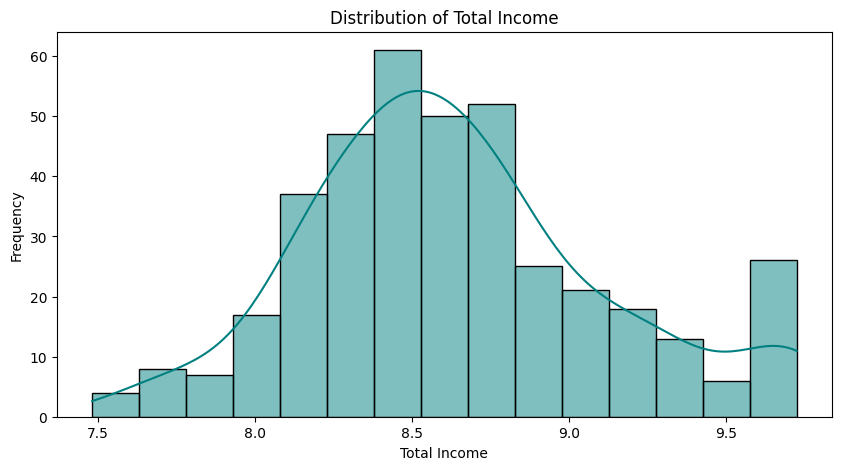

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.histplot(X_train['Total_Income_log'], kde=True, color='teal')
plt.title('Distribution of Total Income')
plt.xlabel('Total Income')
plt.ylabel('Frequency')
plt.show()

In [58]:
X_train.head()

,Dependents,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Total_Income_log
285,2.0,72.0,360.0,0.0,True,True,False,False,True,False,8.517393
38,1.0,151.0,360.0,1.0,True,True,False,False,True,False,8.801319
59,3.0,270.0,300.0,1.0,True,True,False,False,False,True,9.725134
301,2.0,167.0,360.0,1.0,False,True,False,False,False,True,8.089482
346,0.0,118.0,360.0,0.0,True,False,False,False,False,False,8.744807


In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols_to_scale = [
    'Total_Income_log',
    'LoanAmount',
    'Loan_Amount_Term'
]

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [60]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

In [61]:
y_train.value_counts()

,count
Loan_Status,
0,274
1,274


In [62]:
y_test.value_counts()

,count
Loan_Status,
1,69
0,30


In [63]:
X_train.head()

,Dependents,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Total_Income_log
0,2.0,-1.154438,0.291043,0.0,True,True,False,False,True,False,-0.252099
1,1.0,0.218422,0.291043,1.0,True,True,False,False,True,False,0.340220
2,3.0,2.286400,-0.579865,1.0,True,True,False,False,False,True,2.267459
3,2.0,0.496469,0.291043,1.0,False,True,False,False,False,True,-1.144795
4,0.0,-0.355051,0.291043,0.0,True,False,False,False,False,False,0.222325


In [64]:
X_test.head()

,Dependents,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Total_Income_log
20,0.0,0.079398,0.291043,1.0,True,True,False,False,True,False,-0.352507
154,0.0,-0.094382,0.291043,0.0,False,False,False,True,True,False,-0.433733
334,0.0,-0.320295,0.291043,1.0,False,False,True,False,False,True,-0.580299
100,2.0,-0.389807,0.291043,1.0,True,True,False,False,True,False,0.030690
415,0.0,-0.007492,0.291043,1.0,True,True,False,False,False,False,0.067877


In [65]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [66]:
y_pred = model.predict(X_test)

In [67]:
y_prob = model.predict_proba(X_test)[:,1]

In [68]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7676767676767676


In [69]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.61      0.63      0.62        30
           1       0.84      0.83      0.83        69

    accuracy                           0.77        99
   macro avg       0.73      0.73      0.73        99
weighted avg       0.77      0.77      0.77        99



In [70]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[19 11]
 [12 57]]


In [71]:
from sklearn.metrics import roc_auc_score

roc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc)

ROC-AUC: 0.8246376811594203


In [72]:
import pandas as pd

coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})

coefficients.sort_values(by='Coefficient', ascending=False).head(10)

,Feature,Coefficient
3,Credit_History,3.587741
8,Property_Area_Semiurban,0.297051
5,Married_Yes,0.275236
4,Gender_Male,0.229200
10,Total_Income_log,0.209970
0,Dependents,0.104059
2,Loan_Amount_Term,-0.010841
9,Property_Area_Urban,-0.267362
7,Self_Employed_Yes,-0.277773
1,LoanAmount,-0.383212


In [73]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],            # Regularization strength
    'penalty': ['l1', 'l2'],                 # Types of regularization
    'solver': ['liblinear', 'saga'],         # Solvers that support l1 and l2
    'max_iter': [1000]
}

# Initialize the grid search
# We use scoring='roc_auc' because we want the best 'ranking' model
grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring='roc_auc', n_jobs=-1)

# Fit to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and the best score
print("Best Parameters:", grid_search.best_params_)
print("Best ROC-AUC from Grid Search:", grid_search.best_score_)

# Use the best model to make predictions
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

Best Parameters: {'C': 100, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
Best ROC-AUC from Grid Search: 0.75574778083869


In [74]:
# Evaluate the tuned model on the actual test set
y_pred_tuned = best_model.predict(X_test)
y_prob_tuned = best_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print("--- Tuned Model Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned)}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_tuned)}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

--- Tuned Model Results ---
Accuracy: 0.7777777777777778
ROC-AUC: 0.8217391304347826

Confusion Matrix:
[[20 10]
 [12 57]]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.67      0.65        30
           1       0.85      0.83      0.84        69

    accuracy                           0.78        99
   macro avg       0.74      0.75      0.74        99
weighted avg       0.78      0.78      0.78        99



In [75]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("--- Random Forest Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf)}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

--- Random Forest Results ---
Accuracy: 0.696969696969697
ROC-AUC: 0.7753623188405797

Confusion Matrix:
[[18 12]
 [18 51]]


/tmp/ipykernel_518/1196839332.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importances, palette='viridis')


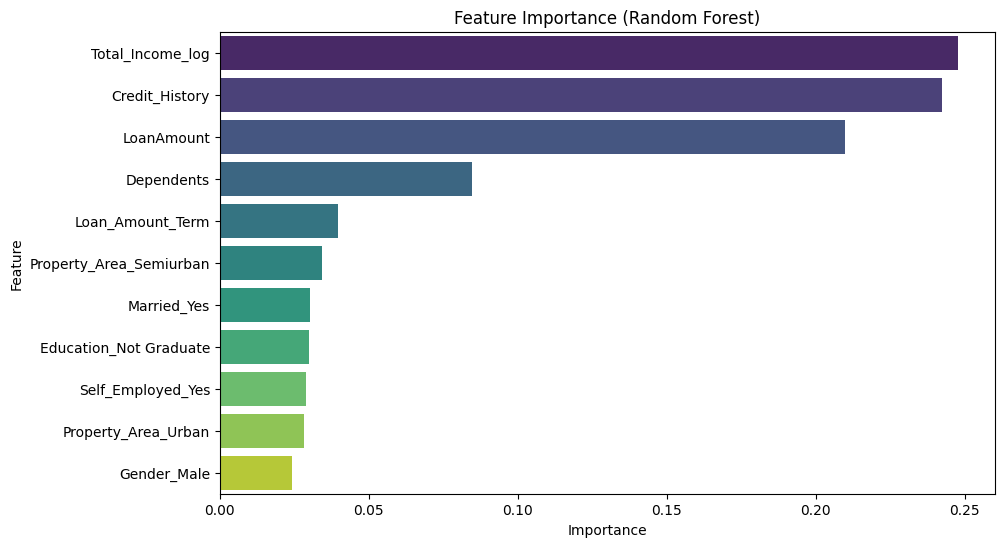

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importances, palette='viridis')
plt.title('Feature Importance (Random Forest)')
plt.show()

In [77]:
import numpy as np
from sklearn.metrics import confusion_matrix

# We use the probabilities from your Tuned Logistic Regression
thresholds = [0.4, 0.5, 0.6, 0.7, 0.8]

print(f"{'Threshold':<12} | {'False Positives (Risk)':<25} | {'False Negatives (Missed Ops)':<25}")
print("-" * 70)

for t in thresholds:
    # Apply the new threshold to the probabilities
    y_pred_t = (y_prob_tuned >= t).astype(int)

    # Get the confusion matrix
    cm = confusion_matrix(y_test, y_pred_t)
    fp = cm[0, 1] # Model said 1, actually 0
    fn = cm[1, 0] # Model said 0, actually 1

    print(f"{t:<12} | {fp:<25} | {fn:<25}")

Threshold    | False Positives (Risk)    | False Negatives (Missed Ops)
----------------------------------------------------------------------
0.4          | 13                        | 5                        
0.5          | 10                        | 12                       
0.6          | 5                         | 25                       
0.7          | 2                         | 46                       
0.8          | 0                         | 62                       


In [79]:
import joblib

# Save the model
joblib.dump(best_model, 'loan_model.joblib')

# Save the scaler (Very Important!)
joblib.dump(scaler, 'scaler.joblib')

# If you used SimpleImputer, save those too
joblib.dump(num_imputer, 'num_imputer.joblib')
joblib.dump(cat_imputer, 'cat_imputer.joblib')

['cat_imputer.joblib']

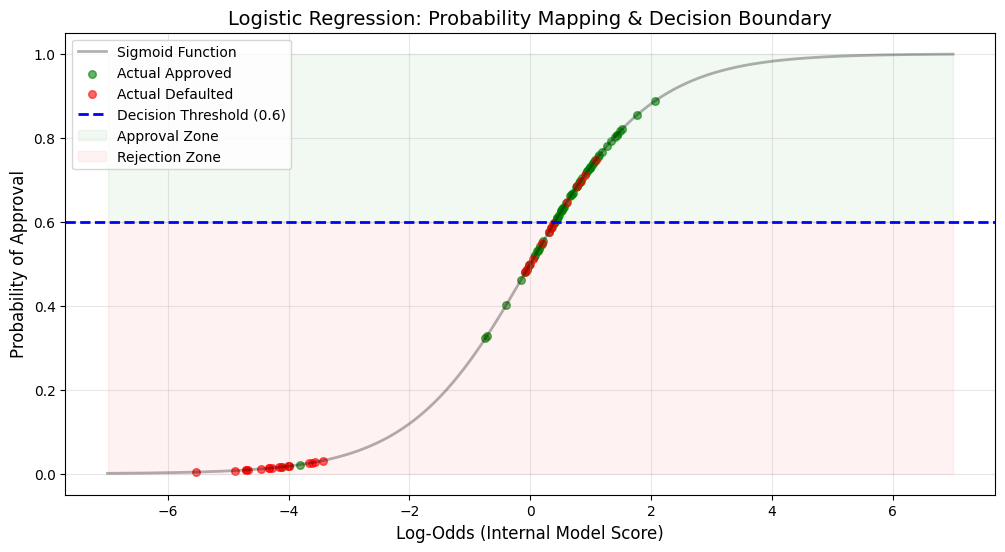

In [81]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate the theoretical Sigmoid Curve
z = np.linspace(-7, 7, 400)
sigmoid = 1 / (1 + np.exp(-z))

# 2. Map your test probabilities (y_prob_tuned) back to Log-Odds (z-space)
# we add a tiny epsilon to avoid log(0) or log(inf) errors
eps = 1e-5
user_z = np.log((y_prob_tuned + eps) / (1 - y_prob_tuned + eps))

# 3. Create the Plot
plt.figure(figsize=(12, 6))

# Plot the main Sigmoid line
plt.plot(z, sigmoid, color='black', linewidth=2, label='Sigmoid Function', alpha=0.3)

# 4. Plot the applicants
# We color them by their actual outcome (y_test) to see if the model was right!
plt.scatter(user_z[y_test==1], y_prob_tuned[y_test==1], color='green', label='Actual Approved', s=30, alpha=0.6)
plt.scatter(user_z[y_test==0], y_prob_tuned[y_test==0], color='red', label='Actual Defaulted', s=30, alpha=0.6)

# 5. Add the Custom Threshold Line
threshold = 0.6
plt.axhline(y=threshold, color='blue', linestyle='--', linewidth=2, label=f'Decision Threshold ({threshold})')

# 6. Formatting for the Case Study
plt.fill_between(z, threshold, 1, color='green', alpha=0.05, label='Approval Zone')
plt.fill_between(z, 0, threshold, color='red', alpha=0.05, label='Rejection Zone')

plt.title('Logistic Regression: Probability Mapping & Decision Boundary', fontsize=14)
plt.xlabel('Log-Odds (Internal Model Score)', fontsize=12)
plt.ylabel('Probability of Approval', fontsize=12)
plt.grid(alpha=0.3)
plt.legend(loc='upper left')

plt.show()